In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from collections import deque
import os

os.makedirs("images",exist_ok=True)

files={
"sudoku.png":"https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png",
"smarties.png":"https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png",
"coins.jpg":"https://raw.githubusercontent.com/opencv/opencv/master/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg",
"dog.jpeg":"https://raw.githubusercontent.com/PacktPublishing/Computer-Vision-Projects-with-OpenCV-and-Python-3/master/Chapter02/test_images/dog.jpeg",
"brain.jpg":"https://raw.githubusercontent.com/PasanAbeysekara/Image-Segmentation-Techniques/main/input/brain_image.jpg"
}

for name,url in files.items():
    if not os.path.exists("images/"+name):
        urlretrieve(url,"images/"+name)

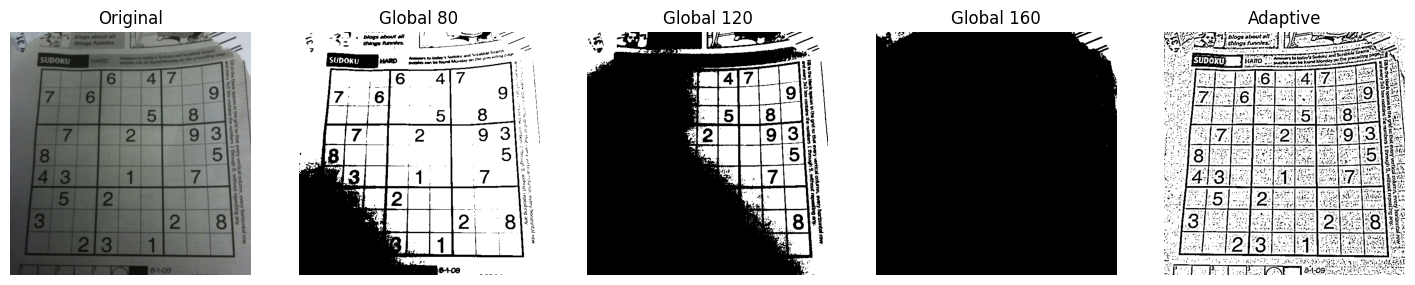

In [2]:
# Task 1

img=cv2.imread("images/sudoku.png")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

vals=[80,120,160]
masks=[]

for t in vals:
    _,m=cv2.threshold(gray,t,255,cv2.THRESH_BINARY)
    masks.append(m)

adaptive=cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)

plt.figure(figsize=(18,4))
plt.subplot(1,5,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Original")

for i,m in enumerate(masks):
    plt.subplot(1,5,i+2)
    plt.imshow(m,cmap="gray")
    plt.axis("off")
    plt.title("Global "+str(vals[i]))

plt.subplot(1,5,5)
plt.imshow(adaptive,cmap="gray")
plt.axis("off")
plt.title("Adaptive")
plt.show()

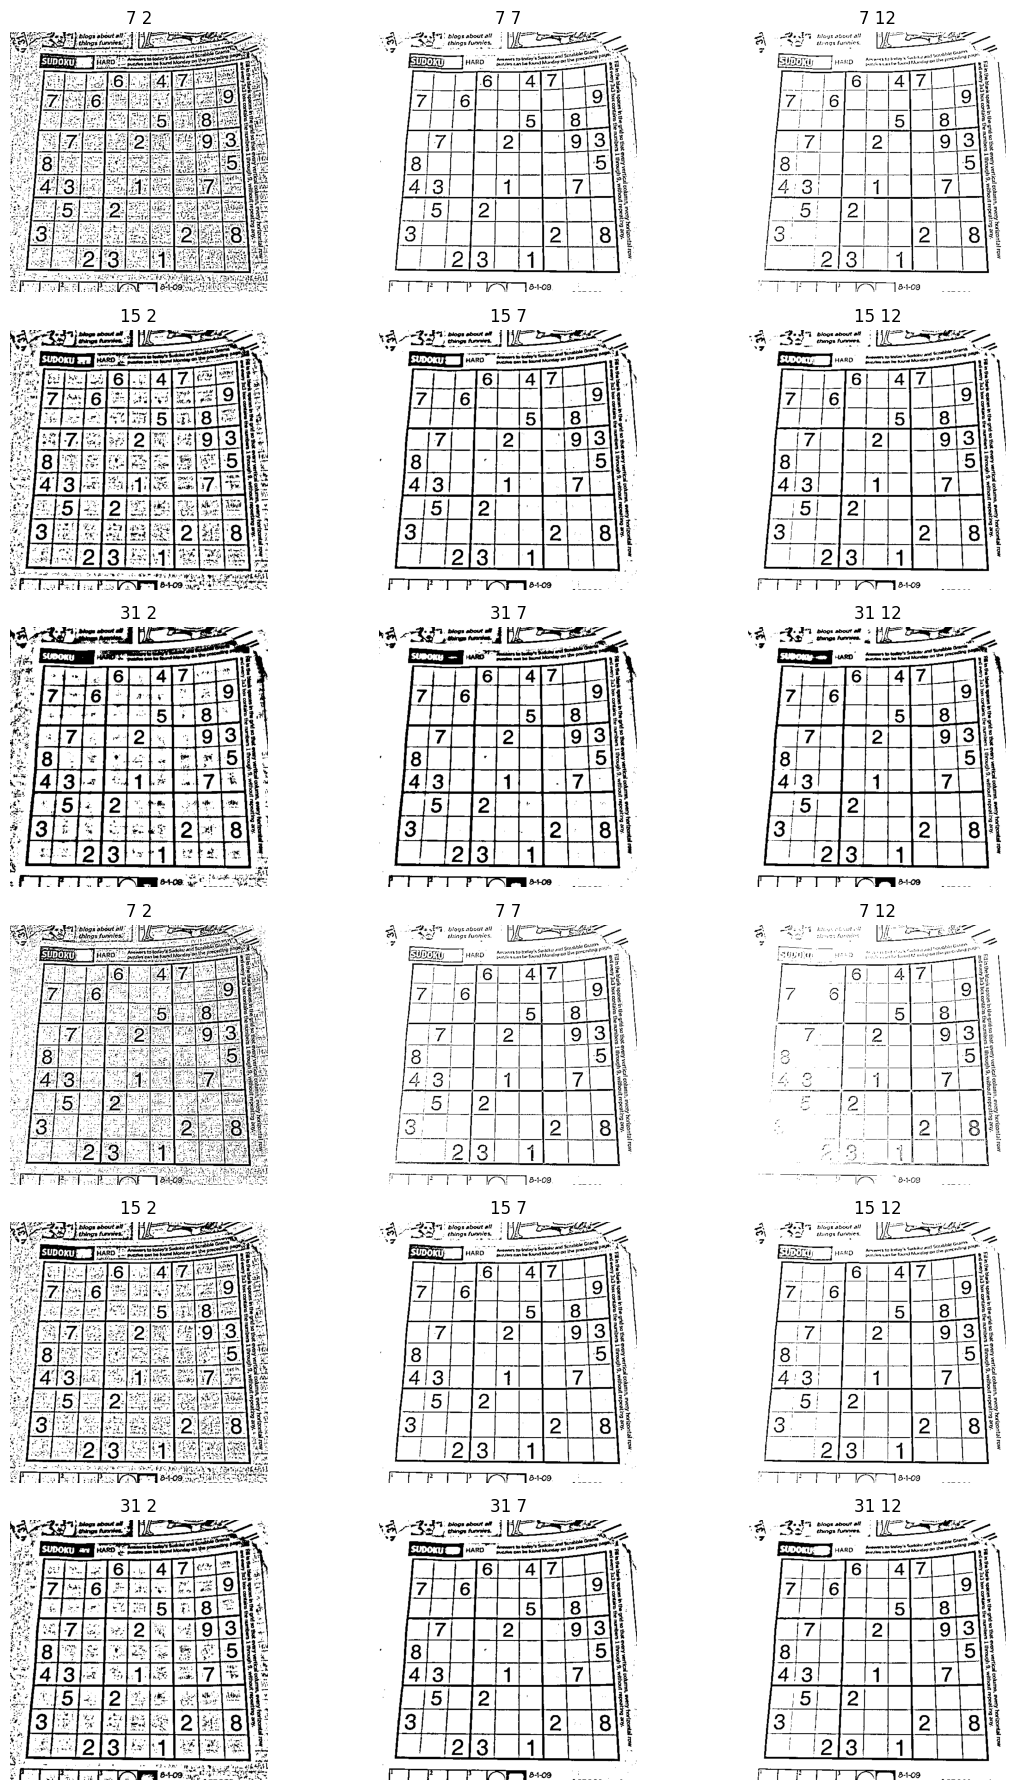

In [3]:
# Task 2

gray=cv2.imread("images/sudoku.png",0)

blocks=[7,15,31]
cs=[2,7,12]

plt.figure(figsize=(12,18))
p=1

for method in [cv2.ADAPTIVE_THRESH_MEAN_C,cv2.ADAPTIVE_THRESH_GAUSSIAN_C]:
    for b in blocks:
        for c in cs:
            out=cv2.adaptiveThreshold(gray,255,method,cv2.THRESH_BINARY,b,c)
            plt.subplot(6,3,p)
            plt.imshow(out,cmap="gray")
            plt.axis("off")
            plt.title(str(b)+" "+str(c))
            p+=1

plt.tight_layout()
plt.show()

/tmp/ipykernel_1169/3446161602.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(),256,[0,256])
/tmp/ipykernel_1169/3446161602.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(changed.ravel(),256,[0,256])


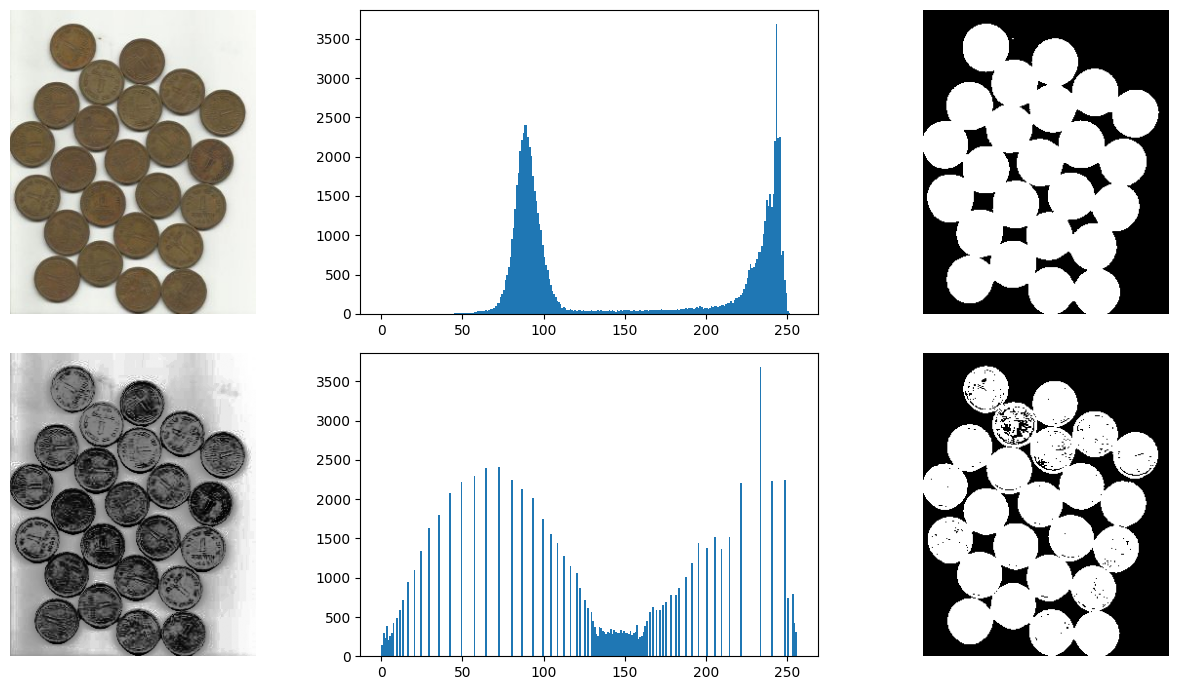

162.0
131.0


In [4]:
# Task 3

img=cv2.imread("images/coins.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

t1,mask1=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

changed=cv2.equalizeHist(gray)
t2,mask2=cv2.threshold(changed,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

plt.figure(figsize=(14,7))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,2)
plt.hist(gray.ravel(),256,[0,256])

plt.subplot(2,3,3)
plt.imshow(mask1,cmap="gray")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(changed,cmap="gray")
plt.axis("off")

plt.subplot(2,3,5)
plt.hist(changed.ravel(),256,[0,256])

plt.subplot(2,3,6)
plt.imshow(mask2,cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

print(t1)
print(t2)

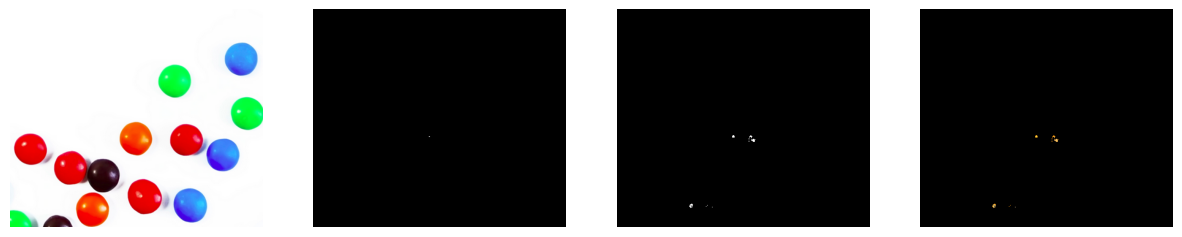

In [5]:
# Task 4

img=cv2.imread("images/smarties.png")
hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

mask1=cv2.inRange(hsv,np.array([25,150,150]),np.array([30,255,255]))
mask2=cv2.inRange(hsv,np.array([18,80,80]),np.array([38,255,255]))

result=cv2.bitwise_and(img,img,mask=mask2)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask1,cmap="gray")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask2,cmap="gray")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

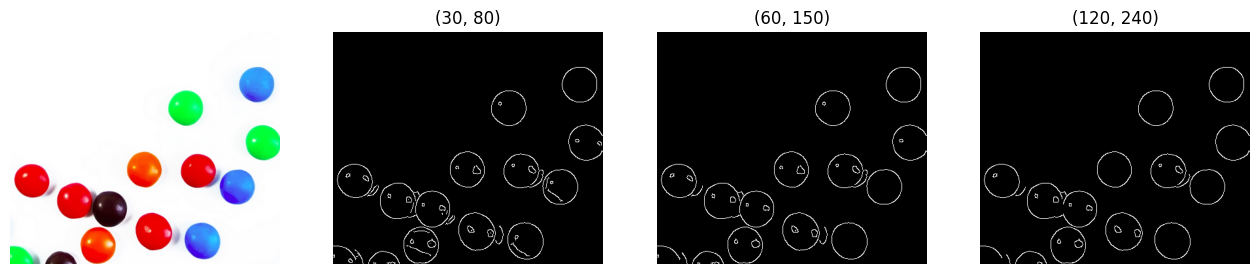

In [6]:
# Task 5

img=cv2.imread("images/smarties.png")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray=cv2.GaussianBlur(gray,(5,5),0)

pairs=[(30,80),(60,150),(120,240)]

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

for i,pair in enumerate(pairs):
    edge=cv2.Canny(gray,pair[0],pair[1])
    plt.subplot(1,4,i+2)
    plt.imshow(edge,cmap="gray")
    plt.axis("off")
    plt.title(str(pair))

plt.show()

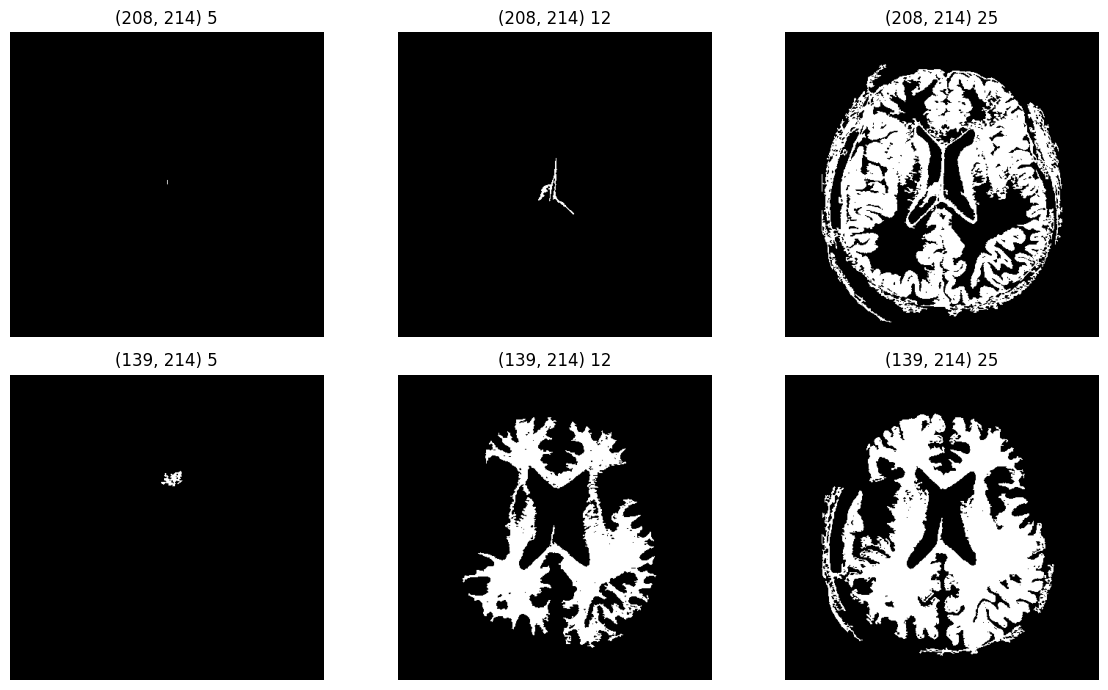

In [7]:
# Task 6

gray=cv2.imread("images/brain.jpg",0)

def grow(img,seed,limit):
    h,w=img.shape
    mask=np.zeros((h,w),np.uint8)
    seen=np.zeros((h,w),np.uint8)
    q=deque([seed])
    start=int(img[seed])

    while q:
        y,x=q.popleft()

        if y<0 or x<0 or y>=h or x>=w or seen[y,x]:
            continue

        seen[y,x]=1

        if abs(int(img[y,x])-start)<=limit:
            mask[y,x]=255
            q.append((y-1,x))
            q.append((y+1,x))
            q.append((y,x-1))
            q.append((y,x+1))

    return mask

h,w=gray.shape
seed1=(h//2,w//2)
seed2=(h//3,w//2)
limits=[5,12,25]

plt.figure(figsize=(12,7))
p=1

for seed in [seed1,seed2]:
    for limit in limits:
        mask=grow(gray,seed,limit)
        plt.subplot(2,3,p)
        plt.imshow(mask,cmap="gray")
        plt.axis("off")
        plt.title(str(seed)+" "+str(limit))
        p+=1

plt.tight_layout()
plt.show()

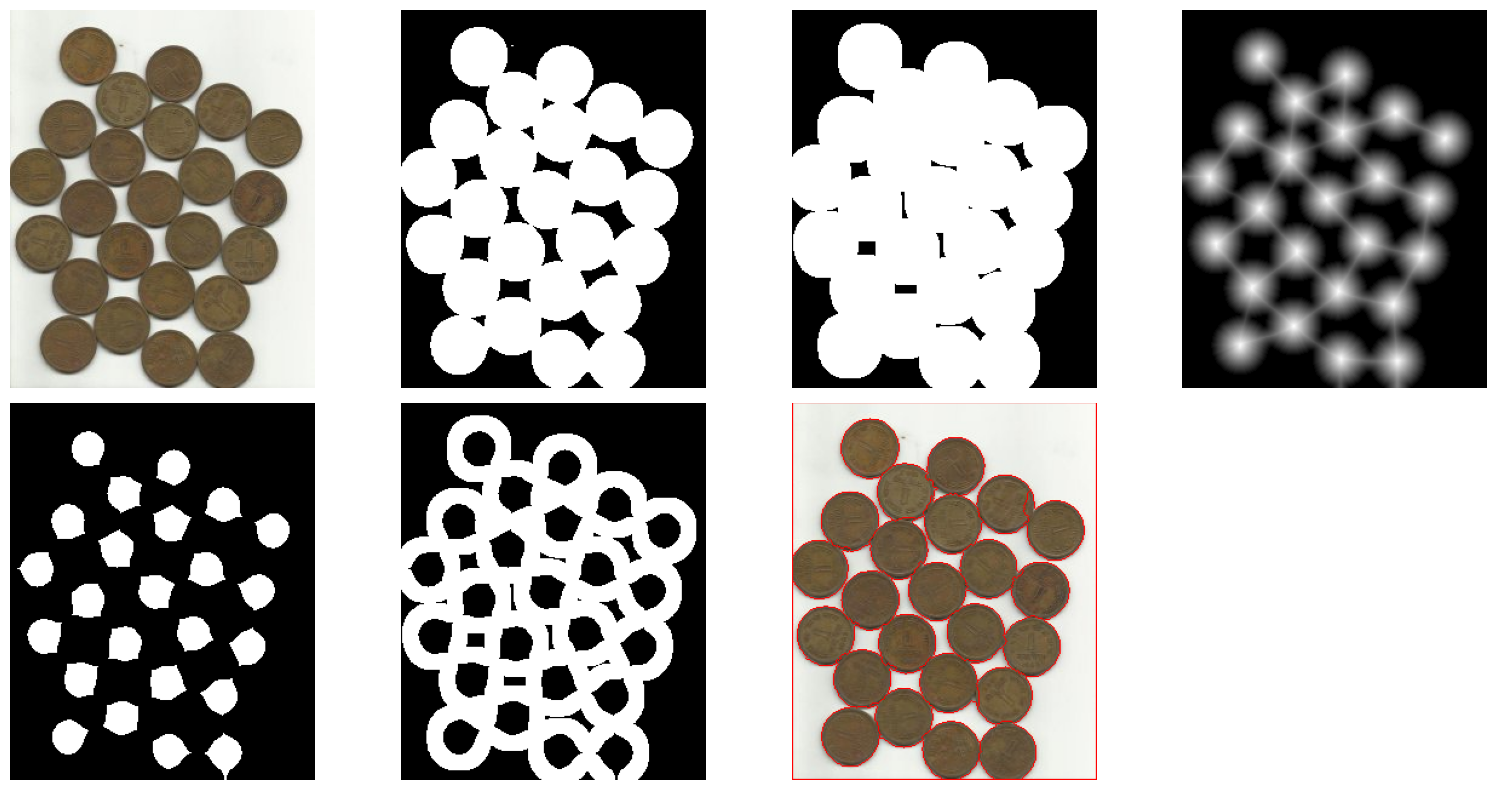

In [8]:
# Task 7

img=cv2.imread("images/coins.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

_,th=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

kernel=np.ones((3,3),np.uint8)
opening=cv2.morphologyEx(th,cv2.MORPH_OPEN,kernel,iterations=2)
bg=cv2.dilate(opening,kernel,iterations=3)

dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)
_,fg=cv2.threshold(dist,0.45*dist.max(),255,0)
fg=np.uint8(fg)

unknown=cv2.subtract(bg,fg)

_,markers=cv2.connectedComponents(fg)
markers=markers+1
markers[unknown==255]=0

markers=cv2.watershed(img,markers)

final=img.copy()
final[markers==-1]=[0,0,255]

items=[img,th,bg,dist,fg,unknown,final]

plt.figure(figsize=(16,8))

for i,x in enumerate(items):
    plt.subplot(2,4,i+1)

    if len(x.shape)==2:
        plt.imshow(x,cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(x,cv2.COLOR_BGR2RGB))

    plt.axis("off")

plt.tight_layout()
plt.show()

0.25 1 1
0.35 5 5
0.45 24 24
0.55 24 24


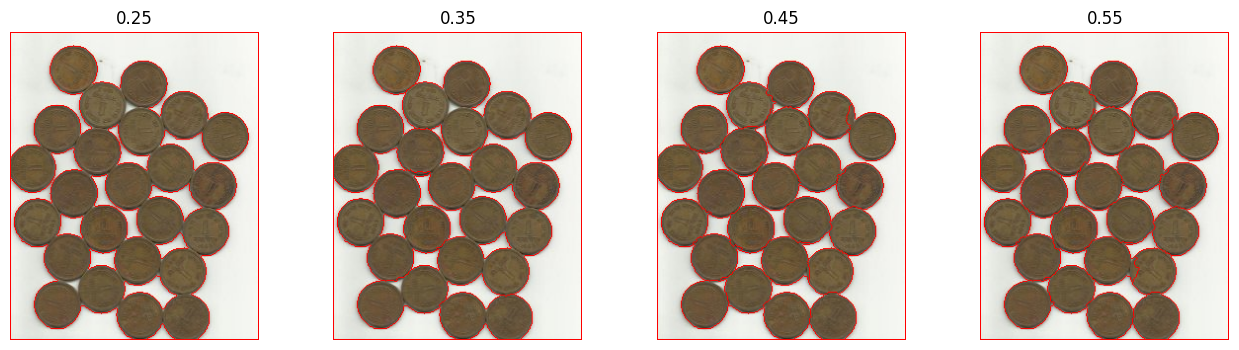

In [9]:
# Task 8

img=cv2.imread("images/coins.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

_,th=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

kernel=np.ones((3,3),np.uint8)
opening=cv2.morphologyEx(th,cv2.MORPH_OPEN,kernel,iterations=2)
bg=cv2.dilate(opening,kernel,iterations=3)
dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)

vals=[0.25,0.35,0.45,0.55]

plt.figure(figsize=(16,4))

for i,v in enumerate(vals):
    _,fg=cv2.threshold(dist,v*dist.max(),255,0)
    fg=np.uint8(fg)

    unknown=cv2.subtract(bg,fg)

    n,markers=cv2.connectedComponents(fg)
    markers=markers+1
    markers[unknown==255]=0

    markers=cv2.watershed(img.copy(),markers)

    out=img.copy()
    out[markers==-1]=[0,0,255]

    regions=len([x for x in np.unique(markers) if x>1])

    print(v,n-1,regions)

    plt.subplot(1,4,i+1)
    plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(str(v))

plt.show()

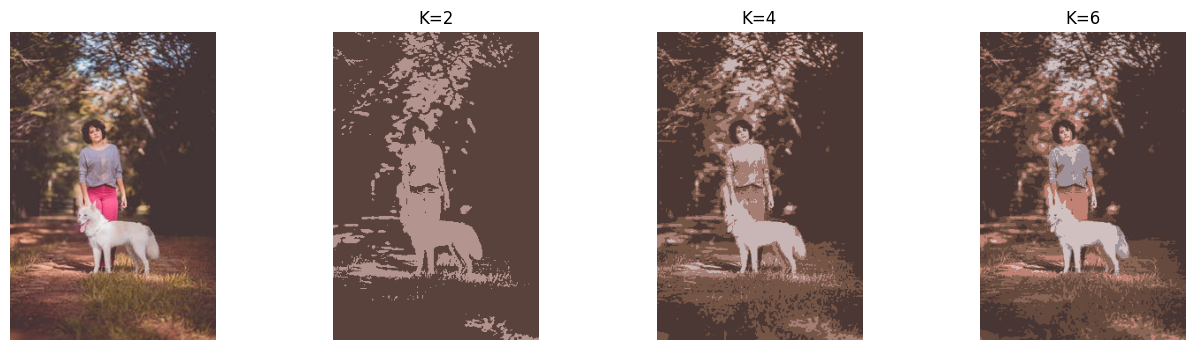

In [10]:
# Task 9

img=cv2.imread("images/dog.jpeg")
rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

pixels=rgb.reshape((-1,3)).astype(np.float32)
criteria=(cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER,100,0.2)

ks=[2,4,6]

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(rgb)
plt.axis("off")

for i,k in enumerate(ks):
    _,labels,centers=cv2.kmeans(pixels,k,None,criteria,10,cv2.KMEANS_PP_CENTERS)
    centers=np.uint8(centers)
    out=centers[labels.flatten()].reshape(rgb.shape)

    plt.subplot(1,4,i+2)
    plt.imshow(out)
    plt.axis("off")
    plt.title("K="+str(k))

plt.show()

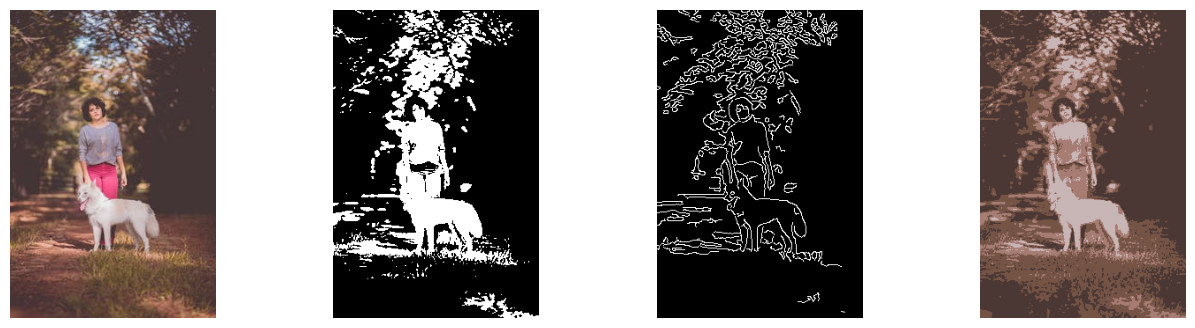

In [11]:
# Task 10

img=cv2.imread("images/dog.jpeg")
rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

_,otsu=cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

blur=cv2.GaussianBlur(gray,(5,5),0)
canny=cv2.Canny(blur,60,150)

pixels=rgb.reshape((-1,3)).astype(np.float32)
criteria=(cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER,100,0.2)

_,labels,centers=cv2.kmeans(pixels,4,None,criteria,10,cv2.KMEANS_PP_CENTERS)
centers=np.uint8(centers)
kmeans=centers[labels.flatten()].reshape(rgb.shape)

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(otsu,cmap="gray")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(canny,cmap="gray")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(kmeans)
plt.axis("off")

plt.show()